<a href="https://colab.research.google.com/github/J4SIB/ai-course-gp/blob/main/Transfer_stylu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transfer stylu


In [46]:
#1 Import bibliotek
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [47]:
#2 Funkcja ładująca grafikę
content_path = "content4.webp"
style_path = "style2.webp"

def load_image(path,max_dim=512):
  img = Image.open(path).convert('RGB')
  scale = max_dim / max(img.size)
  new_size = (int(img.size[0] * scale), int(img.size[1] * scale))
  img = img.resize(new_size, Image.Resampling.LANCZOS)
  img = np.array(img).astype(np.float32)
  return img

content_image = load_image(content_path)
style_image = load_image(style_path)

In [48]:
#3 Przetwarzanie obrazu
def preprocess(image):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    return preprocess_input(image)


def gram_matrix(tensor):
    result = tf.linalg.einsum('bijc,bijd->bcd', tensor, tensor)
    input_shape = tf.shape(tensor)
    num_locations = tf.cast(input_shape[1] * input_shape[2], tf.float32)
    return result / num_locations

In [49]:
#4 Wczytanie obrazów stylu i treści


In [50]:
#5 Wybór warstw stylu i treści
layer_names = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1',
]

style_layers = layer_names[:-1]
content_layer = layer_names[-1]

In [51]:
#6 Budowa modelu i ekstrakcja cech
vgg = VGG16(include_top=False, weights='imagenet')
vgg.trainable = False
outputs = [vgg.get_layer(name).output for name in layer_names]
extractor_model = Model(inputs=vgg.input, outputs=outputs)

def extract_features(image):
    if image.ndim == 3:
        image = tf.expand_dims(image, axis=0)
    image = preprocess(image)
    outputs = extractor_model(image)
    return {name: output for name, output in zip(layer_names, outputs)}

style_targets = extract_features(style_image)
content_targets = extract_features(content_image)
style_grams = {name: gram_matrix(style_targets[name]) for name in style_layers}


#7 Inicjalizacja modelu
image = tf.Variable(content_image / 255.0)
style_weight = 1e4
content_weight = 50
opt = tf.optimizers.Adam(learning_rate=0.02)

#8 Funkcja treningu
def train_step(image):
    with tf.GradientTape() as tape:
        outputs = extract_features(image * 255.0)
        content_output = outputs[content_layer]
        style_output = {name: outputs[name] for name in style_layers}

        content_loss = tf.reduce_mean((content_output - content_targets[content_layer]) ** 2)
        style_loss = tf.add_n([
            tf.reduce_mean((gram_matrix(style_output[name]) - style_grams[name]) ** 2)
            for name in style_layers
        ])

        total_loss = style_weight * style_loss + content_weight * content_loss

    grad = tape.gradient(total_loss, image)
    opt.apply_gradients([(grad, image)])
    image.assign(tf.clip_by_value(image, 0.0, 1.0))

In [52]:
#9 Trening
epochs = 10
steps_per_epoch = 100

for epoch in range(epochs):
  for step in range(steps_per_epoch):
    train_step(image)
    print("Step: ",step+1, "/", steps_per_epoch)
  print("Epoch: ",epoch+1, "/", epochs)

Step:  1 / 100
Step:  2 / 100
Step:  3 / 100
Step:  4 / 100
Step:  5 / 100
Step:  6 / 100
Step:  7 / 100
Step:  8 / 100
Step:  9 / 100
Step:  10 / 100
Step:  11 / 100
Step:  12 / 100
Step:  13 / 100
Step:  14 / 100
Step:  15 / 100
Step:  16 / 100
Step:  17 / 100
Step:  18 / 100
Step:  19 / 100
Step:  20 / 100
Step:  21 / 100
Step:  22 / 100
Step:  23 / 100
Step:  24 / 100
Step:  25 / 100
Step:  26 / 100
Step:  27 / 100
Step:  28 / 100
Step:  29 / 100
Step:  30 / 100
Step:  31 / 100
Step:  32 / 100
Step:  33 / 100
Step:  34 / 100
Step:  35 / 100
Step:  36 / 100
Step:  37 / 100
Step:  38 / 100
Step:  39 / 100
Step:  40 / 100
Step:  41 / 100
Step:  42 / 100
Step:  43 / 100
Step:  44 / 100
Step:  45 / 100
Step:  46 / 100
Step:  47 / 100
Step:  48 / 100
Step:  49 / 100
Step:  50 / 100
Step:  51 / 100
Step:  52 / 100
Step:  53 / 100
Step:  54 / 100
Step:  55 / 100
Step:  56 / 100
Step:  57 / 100
Step:  58 / 100
Step:  59 / 100
Step:  60 / 100
Step:  61 / 100
Step:  62 / 100
Step:  63 / 100
S

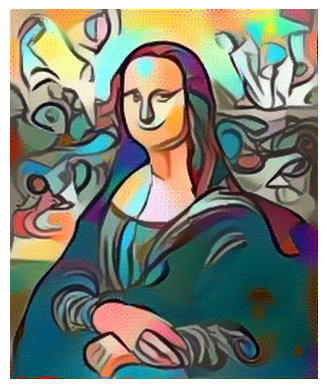

In [53]:
#10 Wyświetlenie wyników
result_img = image.numpy().squeeze()
plt.imshow(result_img)
plt.axis("off")
plt.show()